## REGULARIZATION & HYPERPARAMETER TUNING

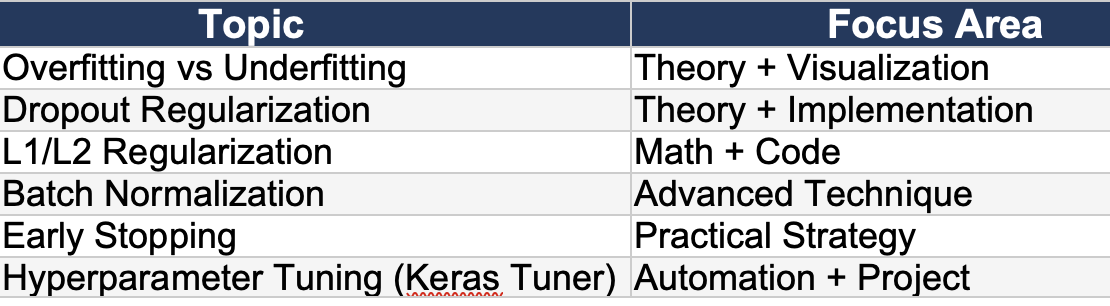

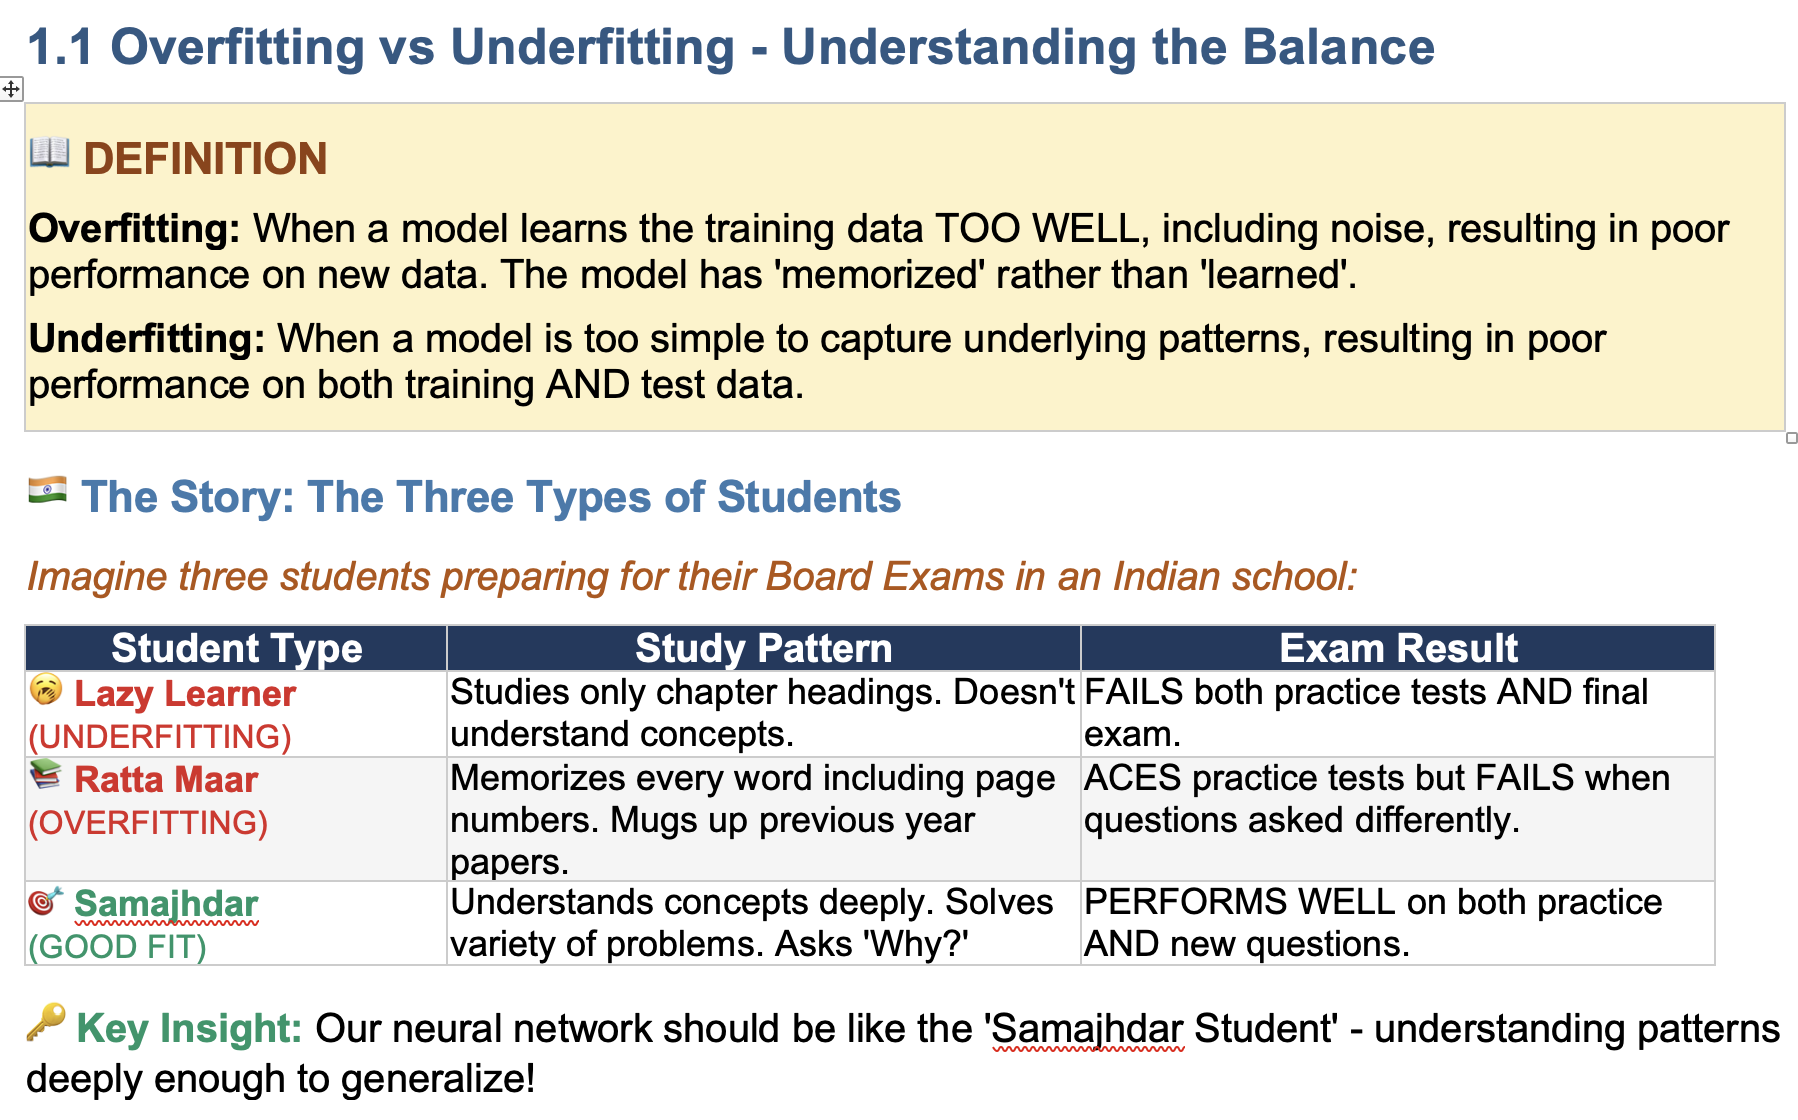

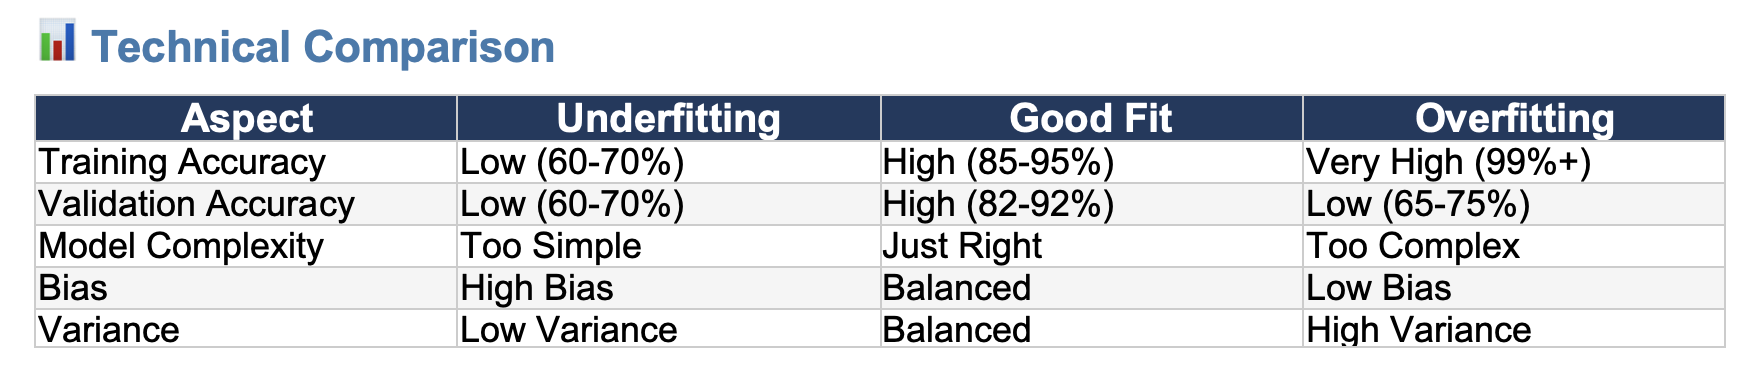

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1, l2, l1_l2
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split


/opt/homebrew/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# =============================================================================
# EXAMPLE 1: DETECTING OVERFITTING VS UNDERFITTING (🟢 EASY)
# Indian Analogy: Three Types of Students
# =============================================================================
print("\n" + "=" * 60)
print("EXAMPLE 1: DETECTING OVERFITTING VS UNDERFITTING")
print("Indian Analogy: The Three Types of Students")
print("=" * 60)

# Generate sample data (Moon dataset - like two chapatis!)
print("\n📊 Generating Moon Dataset...")
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
X_train_moon, X_val_moon, y_train_moon, y_val_moon = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training samples: {len(X_train_moon)}, Validation samples: {len(X_val_moon)}")


EXAMPLE 1: DETECTING OVERFITTING VS UNDERFITTING
Indian Analogy: The Three Types of Students

📊 Generating Moon Dataset...
Training samples: 400, Validation samples: 100


In [3]:
# MODEL 1: UNDERFITTING (Too Simple - Lazy Student / आलसी विद्यार्थी)
print("\n🥱 Creating UNDERFITTING Model (Lazy Student)...")
underfit_model = keras.Sequential([
    layers.Dense(2, activation='relu', input_shape=(2,)),  # Too few neurons!
    layers.Dense(1, activation='sigmoid')
], name='Underfit_Lazy_Student')



🥱 Creating UNDERFITTING Model (Lazy Student)...


/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# MODEL 2: OVERFITTING (Too Complex - Ratta Maar / रट्टा मार)
print("📚 Creating OVERFITTING Model (Ratta Maar)...")
overfit_model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(2,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(256, activation='relu'),  # Way too many neurons!
    layers.Dense(1, activation='sigmoid')
], name='Overfit_Ratta_Maar')

📚 Creating OVERFITTING Model (Ratta Maar)...


In [5]:
# MODEL 3: GOOD FIT (Just Right - Samajhdar / समझदार विद्यार्थी)
print("🎯 Creating GOOD FIT Model (Samajhdar Student)...")
goodfit_model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(2,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
], name='GoodFit_Samajhdar')

🎯 Creating GOOD FIT Model (Samajhdar Student)...


In [6]:
# Compile all models
for model in [underfit_model, overfit_model, goodfit_model]:
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )


In [7]:
# Train and capture history
print("\n🏋️ Training all three models...")
history_under = underfit_model.fit(
    X_train_moon, y_train_moon,
    validation_data=(X_val_moon, y_val_moon),
    epochs=100, verbose=0
)

history_over = overfit_model.fit(
    X_train_moon, y_train_moon,
    validation_data=(X_val_moon, y_val_moon),
    epochs=100, verbose=0
)

history_good = goodfit_model.fit(
    X_train_moon, y_train_moon,
    validation_data=(X_val_moon, y_val_moon),
    epochs=100, verbose=0
)


🏋️ Training all three models...


In [8]:
# Visualization function
def plot_learning_curves(history, title, ax1, ax2):
    """Plot training vs validation loss and accuracy"""
    # Plot Loss
    ax1.plot(history.history['loss'], 'b-', label='Training Loss', linewidth=2)
    ax1.plot(history.history['val_loss'], 'r--', label='Validation Loss', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} - Loss Curves')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot Accuracy
    ax2.plot(history.history['accuracy'], 'b-', label='Training Acc', linewidth=2)
    ax2.plot(history.history['val_accuracy'], 'r--', label='Validation Acc', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title} - Accuracy Curves')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

# Create visualization
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

plot_learning_curves(history_under, 'UNDERFITTING (Lazy Student)', axes[0, 0], axes[0, 1])
plot_learning_curves(history_over, 'OVERFITTING (Ratta Maar)', axes[1, 0], axes[1, 1])
plot_learning_curves(history_good, 'GOOD FIT (Samajhdar)', axes[2, 0], axes[2, 1])

plt.tight_layout()
plt.savefig('Day09_Example1_Overfitting_Detection.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ Visualization saved: Day09_Example1_Overfitting_Detection.png")


✅ Visualization saved: Day09_Example1_Overfitting_Detection.png


In [9]:
# Print results
print("\n📊 RESULTS COMPARISON:")
print("-" * 50)
print(f"{'Model':<25} {'Train Acc':<15} {'Val Acc':<15}")
print("-" * 50)
print(f"{'Underfit (Lazy)':<25} {history_under.history['accuracy'][-1]:.4f}         {history_under.history['val_accuracy'][-1]:.4f}")
print(f"{'Overfit (Ratta Maar)':<25} {history_over.history['accuracy'][-1]:.4f}         {history_over.history['val_accuracy'][-1]:.4f}")
print(f"{'Good Fit (Samajhdar)':<25} {history_good.history['accuracy'][-1]:.4f}         {history_good.history['val_accuracy'][-1]:.4f}")


📊 RESULTS COMPARISON:
--------------------------------------------------
Model                     Train Acc       Val Acc        
--------------------------------------------------
Underfit (Lazy)           0.8550         0.8500
Overfit (Ratta Maar)      0.9875         0.9600
Good Fit (Samajhdar)      0.9825         0.9800


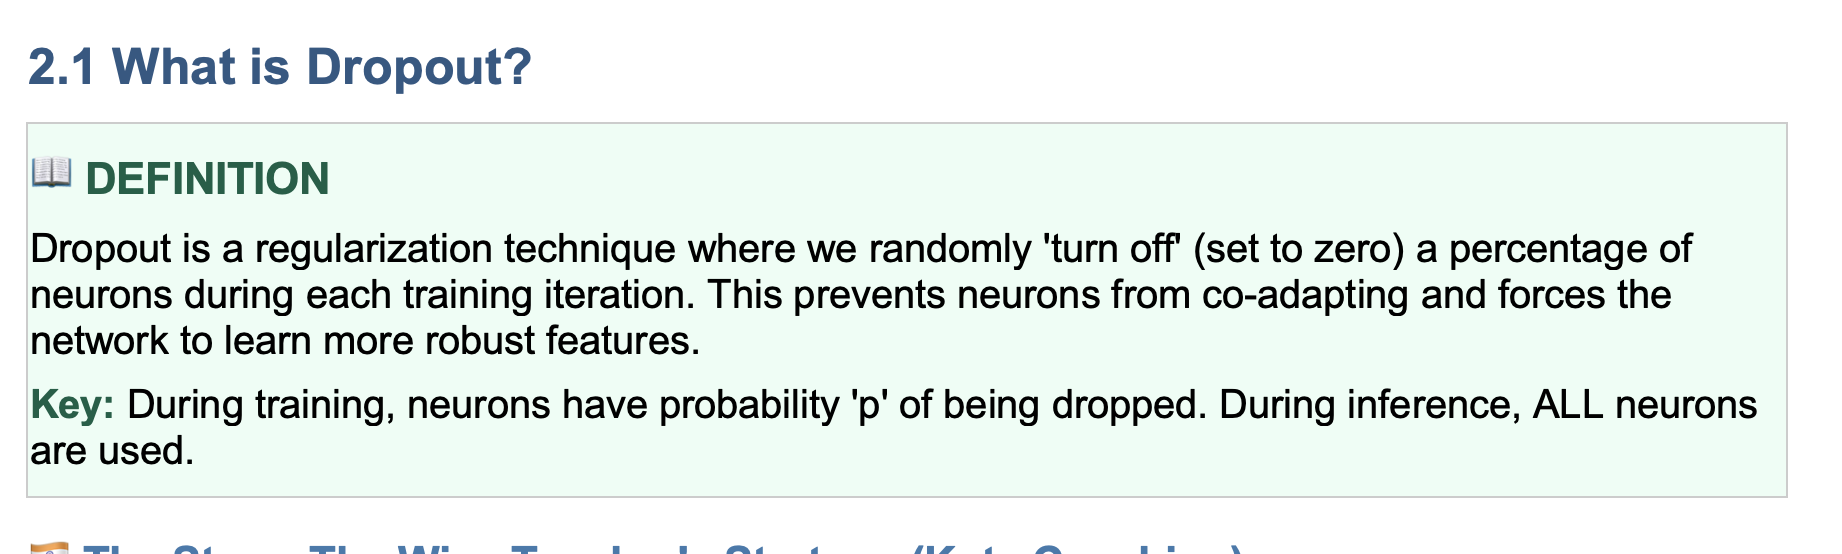

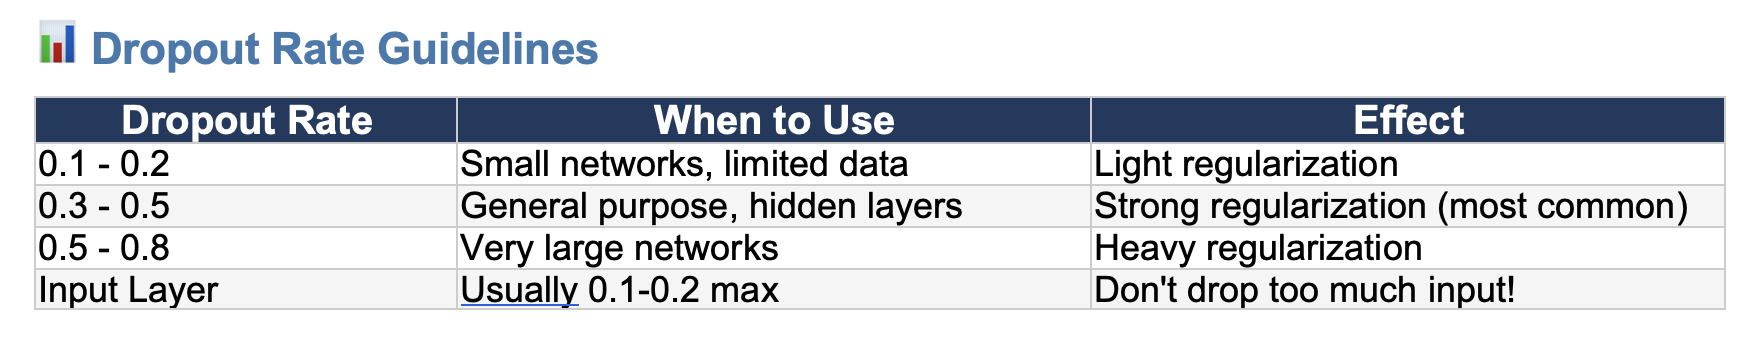

In [10]:
# =============================================================================
# EXAMPLE 2: DROPOUT REGULARIZATION (🟡 MEDIUM)
# Indian Analogy: Kota Coaching Strategy
# =============================================================================
print("\n" + "=" * 60)
print("EXAMPLE 2: DROPOUT REGULARIZATION")
print("Indian Analogy: Sharma Sir's Kota Coaching Strategy")
print("=" * 60)

# Load MNIST dataset
print("\n📊 Loading MNIST Dataset...")
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Preprocess - Normalize to 0-1 range
X_train_flat = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test_flat = X_test.reshape(-1, 784).astype('float32') / 255.0

print(f"Training samples: {len(X_train_flat)}, Test samples: {len(X_test_flat)}")


EXAMPLE 2: DROPOUT REGULARIZATION
Indian Analogy: Sharma Sir's Kota Coaching Strategy

📊 Loading MNIST Dataset...
Training samples: 60000, Test samples: 10000


In [11]:
# MODEL WITHOUT DROPOUT (Prone to Overfitting - All students always present)
print("\n❌ Creating Model WITHOUT Dropout...")
model_no_dropout = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='No_Dropout')


❌ Creating Model WITHOUT Dropout...


In [12]:
# MODEL WITH DROPOUT (Regularized - Sharma Sir's Strategy)
print("✅ Creating Model WITH Dropout (Sharma Sir's Strategy)...")
model_with_dropout = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dropout(0.3),  # 30% students absent each day
    
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),  # Different students absent
    
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),  # Everyone learns independently!
    
    layers.Dense(10, activation='softmax')  # Exam day - all present
], name='With_Dropout')

✅ Creating Model WITH Dropout (Sharma Sir's Strategy)...


In [13]:
# Compile both models
for model in [model_no_dropout, model_with_dropout]:
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

# Train both models
print("\n🏋️ Training Model WITHOUT Dropout...")
history_no_drop = model_no_dropout.fit(
    X_train_flat, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    verbose=0
)
print("🏋️ Training Model WITH Dropout...")
history_with_drop = model_with_dropout.fit(
    X_train_flat, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    verbose=0
)


🏋️ Training Model WITHOUT Dropout...
🏋️ Training Model WITH Dropout...


In [14]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Without Dropout
axes[0].plot(history_no_drop.history['loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].plot(history_no_drop.history['val_loss'], 'r--', label='Val Loss', linewidth=2)
axes[0].set_title('WITHOUT Dropout - All Students Always Present', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# With Dropout
axes[1].plot(history_with_drop.history['loss'], 'b-', label='Train Loss', linewidth=2)
axes[1].plot(history_with_drop.history['val_loss'], 'r--', label='Val Loss', linewidth=2)
axes[1].set_title('WITH Dropout - Sharma Sir Strategy', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Day09_Example2_Dropout_Comparison.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ Visualization saved: Day09_Example2_Dropout_Comparison.png")

✅ Visualization saved: Day09_Example2_Dropout_Comparison.png


In [15]:
# Evaluate on test set
print("\n📊 TEST SET RESULTS:")
print("-" * 50)
test_loss_no, test_acc_no = model_no_dropout.evaluate(X_test_flat, y_test, verbose=0)
test_loss_with, test_acc_with = model_with_dropout.evaluate(X_test_flat, y_test, verbose=0)
print(f"Without Dropout: {test_acc_no*100:.2f}% accuracy")
print(f"With Dropout:    {test_acc_with*100:.2f}% accuracy")


📊 TEST SET RESULTS:
--------------------------------------------------
Without Dropout: 98.08% accuracy
With Dropout:    98.26% accuracy


## L1/L2 REGULARIZATION

    No Regularization
        Unlimited Fund
            Anything
    L1 (Lasso)
        Imported Flowers    =>  0
        Guest               =>  0
    L2  (Ridge)
        Imported Flower     =>  50Lac   =>  10%
        Guest               =>  1CR     =>  10%
    Elastic Net

In [16]:
# =============================================================================
# EXAMPLE 3: L1/L2 REGULARIZATION (🔴 HARD)
# Indian Analogy: Wedding Budget Planner
# =============================================================================
print("\n" + "=" * 60)
print("EXAMPLE 3: L1/L2 REGULARIZATION")
print("Indian Analogy: Big Fat Indian Wedding Budget")
print("=" * 60)


EXAMPLE 3: L1/L2 REGULARIZATION
Indian Analogy: Big Fat Indian Wedding Budget


In [17]:
# L1 Regularized Model (Sparse - Cut unnecessary wedding items completely)
print("\n✂️ Creating L1 Model (Cut unnecessary items - ₹0 for extras)...")
model_l1 = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,),
                kernel_regularizer=l1(0.001)),
    layers.Dense(128, activation='relu',
                kernel_regularizer=l1(0.001)),
    layers.Dense(10, activation='softmax')
], name='L1_Wedding_Cutter')


✂️ Creating L1 Model (Cut unnecessary items - ₹0 for extras)...


In [18]:
# L2 Regularized Model (Weight Decay - Reduce all proportionally)
print("📉 Creating L2 Model (Reduce everything proportionally)...")
model_l2 = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,),
                kernel_regularizer=l2(0.001)),
    layers.Dense(128, activation='relu',
                kernel_regularizer=l2(0.001)),
    layers.Dense(10, activation='softmax')
], name='L2_Wedding_Reducer')

📉 Creating L2 Model (Reduce everything proportionally)...


In [20]:
# Elastic Net (Best of Both Worlds - Smart Planner)
print("🎯 Creating Elastic Net Model (Smart planner - best of both)...")
model_elastic = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,),
                kernel_regularizer=l1_l2(l1=0.0005, l2=0.0005)),
    layers.Dense(128, activation='relu',
                kernel_regularizer=l1_l2(l1=0.0005, l2=0.0005)),
    layers.Dense(10, activation='softmax')
], name='ElasticNet_Smart_Planner')

🎯 Creating Elastic Net Model (Smart planner - best of both)...


In [21]:
# Compile and train
for model in [model_l1, model_l2, model_elastic]:
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

In [22]:
print("\n🏋️ Training L1, L2, and Elastic Net models...")
history_l1 = model_l1.fit(X_train_flat, y_train, validation_split=0.2, epochs=15, batch_size=128, verbose=0)
history_l2 = model_l2.fit(X_train_flat, y_train, validation_split=0.2, epochs=15, batch_size=128, verbose=0)
history_elastic = model_elastic.fit(X_train_flat, y_train, validation_split=0.2, epochs=15, batch_size=128, verbose=0)


🏋️ Training L1, L2, and Elastic Net models...


In [23]:
#  Analyze weight sparsity
def analyze_weights(model, name):
    """Count zero and near-zero weights"""
    total_weights = 0
    zero_weights = 0
    near_zero = 0  # |w| < 0.01
    
    for layer in model.layers:
        weights = layer.get_weights()
        if len(weights) > 0:
            w = weights[0].flatten()
            total_weights += len(w)
            zero_weights += np.sum(w == 0)
            near_zero += np.sum(np.abs(w) < 0.01)
    
    return {
        'name': name,
        'total': total_weights,
        'zero': zero_weights,
        'near_zero': near_zero,
        'zero_pct': 100 * zero_weights / total_weights,
        'near_zero_pct': 100 * near_zero / total_weights
    }

print("\n📊 WEIGHT SPARSITY ANALYSIS:")
print("-" * 60)
for model, name in [(model_l1, 'L1 (Cutter)'), (model_l2, 'L2 (Reducer)'), (model_elastic, 'Elastic (Smart)')]:
    stats = analyze_weights(model, name)
    print(f"{name}: {stats['near_zero_pct']:.1f}% weights near zero")


📊 WEIGHT SPARSITY ANALYSIS:
------------------------------------------------------------
L1 (Cutter): 98.6% weights near zero
L2 (Reducer): 77.4% weights near zero
Elastic (Smart): 98.0% weights near zero
